In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual aesthetic
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load the dataset with the correct filename
df = pd.read_csv('data/Steel_industry_data.csv')
print(f"Dataset loaded successfully. Shape: {df.shape}")

# Clean up column names to remove any extra spaces
df.columns = df.columns.str.strip()
df.head()

Dataset loaded successfully. Shape: (35040, 11)


,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,01/01/2018 00:15,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
1,01/01/2018 00:30,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
2,01/01/2018 00:45,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
3,01/01/2018 01:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load
4,01/01/2018 01:15,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load


Dataset loaded successfully. Shape: (35040, 17)
Feature engineering complete!
Total number of outliers detected in Usage_kWh: 328


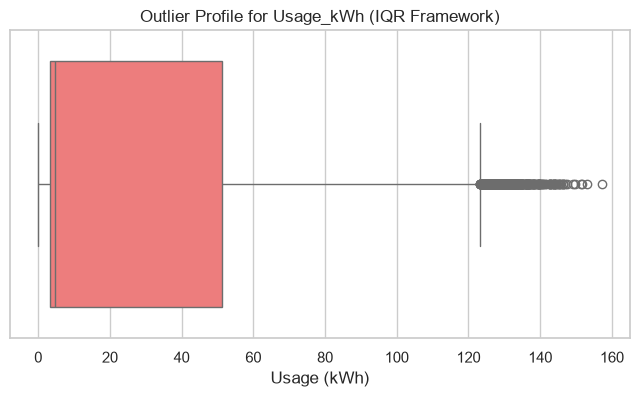

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set visual aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# 2. Load the dataset
df = pd.read_csv('data/Steel_industry_data.csv')
df.columns = df.columns.str.strip()

# 3. Convert timestamp to datetime handling mixed formats safely
df['date'] = pd.to_datetime(df['date'], format='mixed')

# 4. Extract temporal components
df['hour'] = df['date'].dt.hour
df['day_of_week'] = df['date'].dt.day_name()
df['month'] = df['date'].dt.month
df['is_weekend'] = df['date'].dt.weekday.apply(lambda x: 1 if x >= 5 else 0)

# 5. Create Power Factor Ratio
epsilon = 1e-9
df['Power_Factor_Ratio'] = df['Leading_Current_Power_Factor'] / (df['Lagging_Current_Power_Factor'] + epsilon)

# 6. Define High Load Thresholds
q75_usage = df['Usage_kWh'].quantile(0.75)
df['High_Load'] = np.where(df['Usage_kWh'] > q75_usage, 1, 0)

# 7. Calculate Outliers
q25 = df['Usage_kWh'].quantile(0.25)
iqr = q75_usage - q25
lower_bound = q25 - 1.5 * iqr
upper_bound = q75_usage + 1.5 * iqr
outliers = df[(df['Usage_kWh'] < lower_bound) | (df['Usage_kWh'] > upper_bound)]

print(f"Dataset loaded successfully. Shape: {df.shape}")
print("Feature engineering complete!")
print(f"Total number of outliers detected in Usage_kWh: {len(outliers)}")

# 8. Generate the boxplot visualization
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Usage_kWh'], color='#ff6b6b')
plt.title('Outlier Profile for Usage_kWh (IQR Framework)')
plt.xlabel('Usage (kWh)')
plt.show()

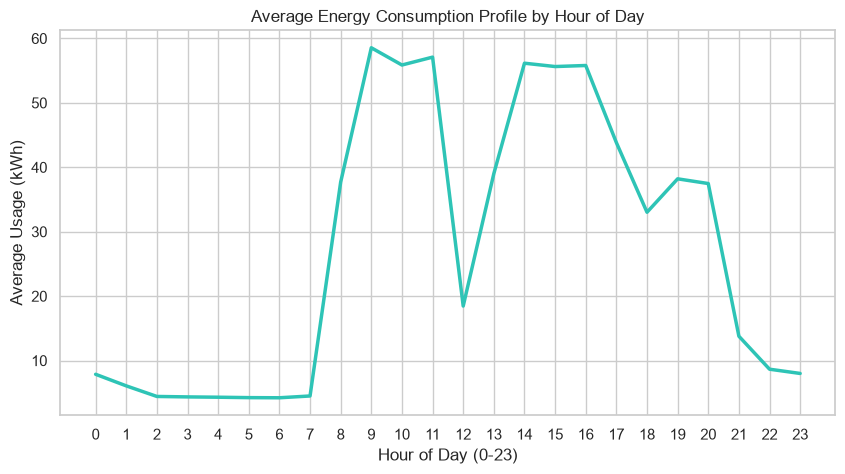

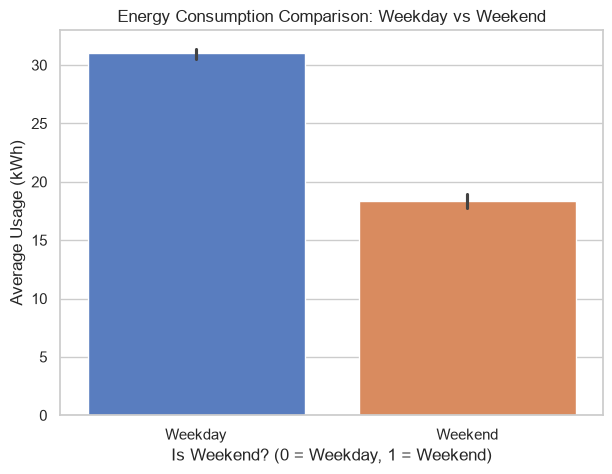

In [5]:
# 1. Energy Usage by Hour of the Day
plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x='hour', y='Usage_kWh', errorbar=None, color='#2ec4b6', linewidth=2.5)
plt.title('Average Energy Consumption Profile by Hour of Day')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Average Usage (kWh)')
plt.xticks(range(0, 24))
plt.show()

# 2. Energy Usage: Weekdays vs Weekends
plt.figure(figsize=(7, 5))
sns.barplot(data=df, x='is_weekend', y='Usage_kWh', hue='is_weekend', palette='muted', legend=False)
plt.title('Energy Consumption Comparison: Weekday vs Weekend')
plt.xlabel('Is Weekend? (0 = Weekday, 1 = Weekend)')
plt.ylabel('Average Usage (kWh)')
plt.xticks([0, 1], ['Weekday', 'Weekend'])
plt.show()